In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sinter
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
from qecsim.xzzx_code.circuit import XZZX_code
from qecsim.threshold_num.calc_threshold import threshold_approx
import pickle
import numpy as np

In [125]:
#XZZX_code(distance = 5, rounds = 5, state_init = "Hor", noise_bias = [1,0,0], after_c_pauli_channel_prob = 0.7).diagram("timeslice-svg", tick = 1)

In [3]:
#Loading Stats with pickle
with open("XZZX_num_value(full_bias).pkl", "rb") as file:
    num_value = pickle.load(file)

In [4]:
array = np.array([[x, y, z, val] for [x, y, z], val in num_value])
array

array([[0.        , 0.        , 1.        , 0.06968798],
       [0.        , 0.05      , 0.95      , 0.03468425],
       [0.        , 0.1       , 0.9       , 0.02962341],
       [0.        , 0.15      , 0.85      , 0.0265859 ],
       [0.        , 0.2       , 0.8       , 0.02521819],
       [0.        , 0.25      , 0.75      , 0.02436099],
       [0.        , 0.3       , 0.7       , 0.0867349 ],
       [0.        , 0.35      , 0.65      , 0.07376493],
       [0.        , 0.4       , 0.6       , 0.07716642],
       [0.        , 0.45      , 0.55      , 0.0815996 ],
       [0.        , 0.5       , 0.5       , 0.01915004],
       [0.        , 0.55      , 0.45      , 0.01868469],
       [0.        , 0.6       , 0.4       , 0.01798822],
       [0.        , 0.65      , 0.35      , 0.0175904 ],
       [0.        , 0.7       , 0.3       , 0.01700225],
       [0.        , 0.75      , 0.25      , 0.01667202],
       [0.        , 0.8       , 0.2       , 0.01670863],
       [0.        , 0.85      ,

In [7]:
"""###################
# Plot 1 dim X Bias
###################

save_bx = []
save_pt = []

for bx, by, bz, pt in array:
    if by == 0 and bz == 0:
        save_bx.append(bx)
        save_pt.append(pt)

plt.scatter(save_bx, save_pt)
plt.grid(True)
plt.xlabel("X Bias")
plt.ylabel("Threshold Value $P_t$")
plt.title("Dependence of X-Bias $P_t(B_X)$ ($B_z = B_y = 0$)")
plt.show()

###################
# Plot 1 dim Y Bias
###################

save_by = []
save_pt = []

for bx, by, bz, pt in array:
    if bx == 0 and bz == 0:
        save_by.append(by)
        save_pt.append(pt)

plt.scatter(save_by, save_pt)
plt.grid(True)
plt.xlabel("Y Bias")
plt.ylabel("Threshold Value $P_t$")
plt.title("Dependence of Y-Bias $P_t(B_Y)$ ($B_x = B_z = 0$)")
plt.show()

###################
# Plot 1 dim Z Bias
###################

save_bz = []
save_pt = []

for bx, by, bz, pt in array:
    if by == 0 and bx == 0:
        save_bz.append(bz)
        save_pt.append(pt)

plt.scatter(save_bz, save_pt)
plt.grid(True)
plt.xlabel("Z Bias")
plt.ylabel("Threshold Value $P_t$")
plt.title("Dependence of Z-Bias $P_t(B_Z)$ ($B_x = B_y = 0$)")
plt.show()"""

'###################\n# Plot 1 dim X Bias\n###################\n\nsave_bx = []\nsave_pt = []\n\nfor bx, by, bz, pt in array:\n    if by == 0 and bz == 0:\n        save_bx.append(bx)\n        save_pt.append(pt)\n\nplt.scatter(save_bx, save_pt)\nplt.grid(True)\nplt.xlabel("X Bias")\nplt.ylabel("Threshold Value $P_t$")\nplt.title("Dependence of X-Bias $P_t(B_X)$ ($B_z = B_y = 0$)")\nplt.show()\n\n###################\n# Plot 1 dim Y Bias\n###################\n\nsave_by = []\nsave_pt = []\n\nfor bx, by, bz, pt in array:\n    if bx == 0 and bz == 0:\n        save_by.append(by)\n        save_pt.append(pt)\n\nplt.scatter(save_by, save_pt)\nplt.grid(True)\nplt.xlabel("Y Bias")\nplt.ylabel("Threshold Value $P_t$")\nplt.title("Dependence of Y-Bias $P_t(B_Y)$ ($B_x = B_z = 0$)")\nplt.show()\n\n###################\n# Plot 1 dim Z Bias\n###################\n\nsave_bz = []\nsave_pt = []\n\nfor bx, by, bz, pt in array:\n    if by == 0 and bx == 0:\n        save_bz.append(bz)\n        save_pt.append(pt

In [6]:
import numpy as np
import plotly.graph_objects as go
from matplotlib.tri import Triangulation

###########################################
# Define probabilites and threshold vectors
###########################################

pX, pY, pZ = array[:,0], array[:,1], array[:,2]
p_c = array[:,3]

######################
# 2.  Diagnostic check
######################

bad = (pX < 0) | (pZ < 0) | (pY < 0)
if bad.any():
    print("Found", bad.sum(), "rows outside the simplex; they are being dropped.")
    pX, pZ, pY, p_c = [v[~bad] for v in (pX, pZ, pY, p_c)]

assert pX.size > 0, "No valid rows remain inside the simplex!"

# ---------------------------------------------------------------
# 3.  Barycentric → Cartesian
x = pX + 0.5*pY
y = (np.sqrt(3)/2)*pY
z = p_c

# ---------------------------------------------------------------
# 4.  Triangulate & plot (identical to before)
tri = Triangulation(x, y)
i, j, k = tri.triangles.T

mesh = go.Mesh3d(
    x=x, y=y, z=z,
    i=i, j=j, k=k,
    intensity=z, colorscale="plasma", flatshading=True,
    colorbar=dict(title="p<sub>c</sub>", thickness=18, x=1.08)
)

base = go.Mesh3d(
    x=[0, 1, 0.5], y=[0, 0, np.sqrt(3)/2], z=[0, 0, 0],
    i=[0], j=[1], k=[2],
    color="lightgrey", opacity=0.5, showscale=False
)

labels = go.Scatter3d(
    x=[0, 1, 0.5], y=[0, 0, np.sqrt(3)/2], z=[0, 0, 0],
    mode="text", text=["Z", "X", "Y"],
    textfont=dict(size=16), showlegend=False
)

fig = go.Figure([mesh, base, labels])
fig.update_layout(
    scene=dict(
        xaxis_title="X", yaxis_title="Z",
        zaxis_title="Threshold error rate  p<sub>c</sub>",
        zaxis_range=[0, 0.55],
        camera=dict(eye=dict(x=1.5, y=0.9, z=0.7))
    ),
    margin=dict(l=0, r=0, b=0, t=0),
    width=640, height=500
)
fig.show()


In [150]:
###################################################
# Number of zero entries -> Still wrong approx here
###################################################

count_pt_zeros = 0

for bx, by, bz, pt in array:
    if pt == 0:
        count_pt_zeros += 1

count_pt_zeros

1

In [151]:
# Running simulation
task_noisy_v = [sinter.Task(
    circuit = XZZX_code(
        distance = d,
        rounds = d, 
        state_init ="Ver",
        noise_bias = [0.1, 0.0, 0.0],
        after_c_pauli_channel_prob = noise
        ),
    json_metadata={'p': noise, 'distance' : d}
    ) 
    for noise in [i for i in np.arange(0.005, 0.1, 0.005)]
    for d in [9, 11]
]


stats_noisy_v : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy_v,
    decoders=['pymatching'],
    max_shots=10_000_000,
    max_errors=10_000,
    print_progress=True
)

Starting 64 workers...
38 tasks left:
  workers    decoder eta shots_left errors_left json_metadata                     
        1 pymatching  2m    9998703       10000 p=0.005,distance=9                
        1 pymatching   ?   10000000       10000 p=0.005,distance=11               
        1 pymatching   ?   10000000       10000 p=0.01,distance=9                 
        1 pymatching   ?   10000000       10000 p=0.01,distance=11                
        1 pymatching   ?   10000000       10000 p=0.015,distance=9                
        1 pymatching   ?   10000000       10000 p=0.015,distance=11               
        1 pymatching   ?   10000000       10000 p=0.02,distance=9                 
        1 pymatching   ?   10000000       10000 p=0.02,distance=11                
        1 pymatching   ?   10000000       10000 p=0.025,distance=9                
        1 pymatching   ?   10000000       10000 p=0.025,distance=11               
        1 pymatching   ?   10000000       10000 p

KeyboardInterrupt: 

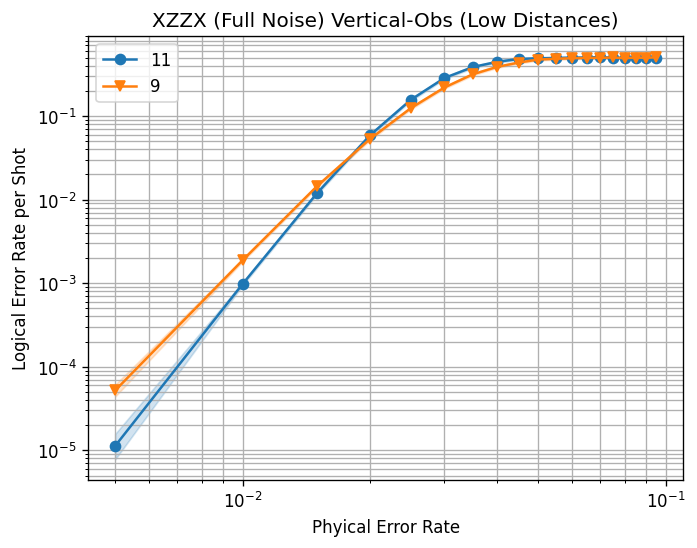

In [ ]:
######################################
# Plotting Noise (Vertical Observable)
######################################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_noisy_v,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_title("XZZX (Full Noise) Vertical-Obs (Low Distances)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

In [ ]:
threshold_approx(stats_noisy_v)

0.017909322689407422